In [29]:
import sys
sys.path.append("../../src/")
from kblock_ising_model import U, k_vals, PZ_n
from time_evolved_z_correlators import  P_n 
from kibble_zurek import state
from common_imports import *

In [37]:
L = 256
k0 = k_vals(L)
U0 = U(k0,0)
def P0(n):
    return PZ_n(n,U0,k0)
def P(n,state=s):
    return P_n(n,state)

In [56]:
taus = np.logspace(-2,2,100)
states = [state(L,t,t) for t in taus]

In [74]:
ns = np.arange(1,8,2)
data = np.zeros([len(ns),len(taus)])
for i in range(len(ns)):
    for j in range(len(taus)):
        data[i,j]= abs(P0(ns[i])-P(ns[i],states[j]))

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Compare_Z_X_projectors/../../src/kblock_ising_model.py:170: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = -D(Nd,T,k)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Compare_Z_X_projectors/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


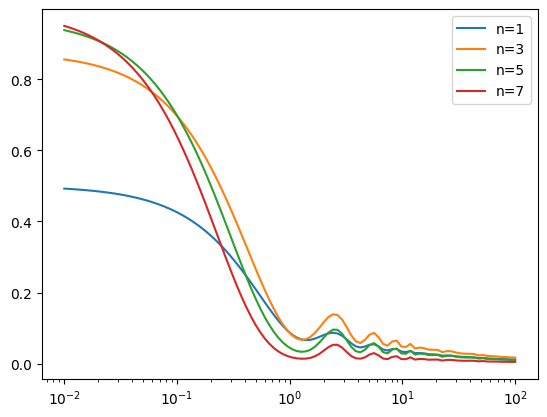

In [75]:
plot(taus,data.T,label=["n="+f"{ni}" for ni in ns])
#plot(taus,taus**(-2))
#ylim(0.1,1)
xscale("log")
#yscale("log")
legend()